# Generating original, ground truth and predicted image and masks for presentations

In [1]:
import torch
from PIL import Image
import torchvision.transforms.functional as TF
import numpy as np
import matplotlib.pyplot as plt
import sys

In [2]:
# --- Model imports ---
sys.path.append('../')
from utils.models.uNet import UNet
from utils.models.SegFormer import segformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [26]:
# --- Load models ---
# U-NET
unet = UNet(in_channels=3, out_channels=1, channels=[32, 64, 128, 256, 512], bilinear=True, use_batchnorm=True)
unet.load_state_dict(torch.load("../models/wheat_U-NET_seg.pt", map_location=device))
unet.to(device).eval()

# SegFormer
segf = segformer(in_channels=3, num_classes=1)
segf.load_state_dict(torch.load("../models/sorghum_SegFormer_seg.pt", map_location=device))
segf.to(device).eval()

segformer(
  (backbone): mix_transformer(
    (stages): ModuleList(
      (0): mix_transformer_stage(
        (patch_embed): overlap_patch_embed(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (blocks): ModuleList(
          (0-1): 2 x transformer_block(
            (attn): efficient_self_attention(
              (sr): Conv2d(32, 32, kernel_size=(8, 8), stride=(8, 8))
              (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
              (q): Linear(in_features=32, out_features=32, bias=True)
              (kv): Linear(in_features=32, out_features=64, bias=True)
              (proj): Linear(in_features=32, out_features=32, bias=True)
            )
            (ffn): mix_feedforward(
              (fc1): Linear(in_features=32, out_features=128, bias=True)
              (fc2): Linear(in_features=128, out_features=32, bias=True)
              (conv

In [34]:
# --- Load image and mask ---
IMG_PATH = "../data/wheat/test/images/1_29_1.jpg"
MASK_PATH = "../data/wheat/test/masks/1_29_1.png"

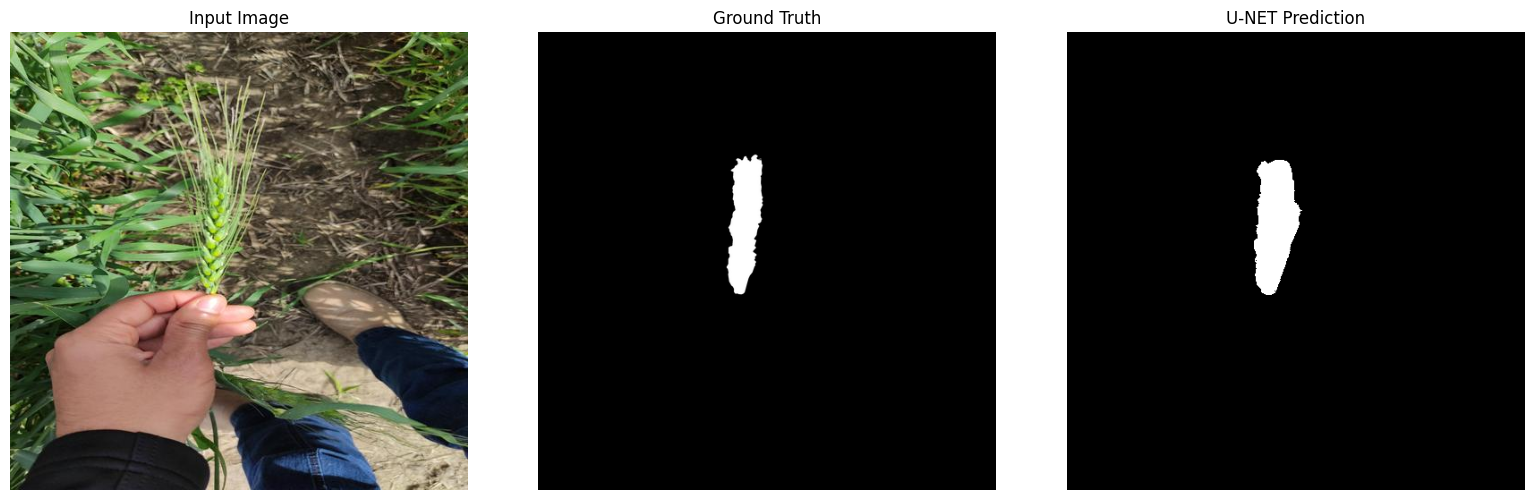

In [35]:
img = Image.open(IMG_PATH).convert("RGB").resize((512, 512))
mask = Image.open(MASK_PATH).convert("L").resize((512, 512))

img_tensor = TF.to_tensor(img)
img_tensor = TF.normalize(img_tensor, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
img_tensor = img_tensor.unsqueeze(0).to(device)

# --- Inference ---
with torch.no_grad():
    pred_unet = torch.sigmoid(unet(img_tensor)).cpu().squeeze().numpy()
    #pred_segf = torch.sigmoid(segf(img_tensor)).cpu().squeeze().numpy()

# --- Threshold predictions ---
pred_unet_bin = (pred_unet > 0.5).astype(np.float32)
#pred_segf_bin = (pred_segf > 0.5).astype(np.float32)

# --- Plot ---
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(img)
axs[0].set_title("Input Image")
axs[1].imshow(mask, cmap='gray')
axs[1].set_title("Ground Truth")
axs[2].imshow(pred_unet_bin, cmap='gray')
axs[2].set_title("U-NET Prediction")
#axs[2].imshow(pred_segf_bin, cmap='gray')
#axs[2].set_title("SegFormer Prediction")
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()